In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats



In [27]:
DATA = '/kaggle/input/datasets/kinzaemannn/fixed-datasets/'
# (Replace YOUR-FIXED-DATASET-PATH with the actual Kaggle path after uploading)

spi = pd.read_csv(DATA + 'spi_prices_clean_FIXED.csv', parse_dates=['Date'])
fao = pd.read_csv(DATA + 'fao_food_supply_clean_FIXED.csv')
wb  = pd.read_csv(DATA + 'worldbank_clean_FIXED.csv')
wb_real = pd.read_csv(DATA + 'worldbank_real_surveys_only.csv')


In [28]:
# ── Exclude unreliable rows from SPI (Quetta Wheat Flour) ─
spi_reliable = spi[spi['Data_Reliable'] == True].copy()

# ── Food-only SPI (no utilities, clothing, etc.) ─────────
non_food_keywords = ['Electricity', 'Gas', 'Petrol', 'Diesel', 'Lpg',
                     'Telephone', 'Cigarettes', 'Georgette', 'Lawn',
                     'Long Cloth', 'Shirting', 'Sandal', 'Chappal',
                     'Energy Saver', 'Firewood', 'Match Box',
                     'Washing Soap', 'Toilet Soap']
pattern = '|'.join(non_food_keywords)
spi_food = spi_reliable[~spi_reliable['Item'].str.contains(pattern, case=False, na=False)].copy()

print('Data loaded successfully')
print(f'  SPI total rows     : {len(spi):,}')
print(f'  SPI reliable rows  : {len(spi_reliable):,}')
print(f'  SPI food-only rows : {len(spi_food):,}')
print(f'  FAO shape          : {fao.shape}')
print(f'  WB all years       : {wb.shape}')
print(f'  WB real surveys    : {wb_real.shape}')


Data loaded successfully
  SPI total rows     : 85,267
  SPI reliable rows  : 85,162
  SPI food-only rows : 53,342
  FAO shape          : (262, 17)
  WB all years       : (25, 8)
  WB real surveys    : (10, 8)


# ─────────────────────────────────────────────────────────────
* EDA 2 (FIXED) — Poverty Rate vs Total Food Supply
* Fix 1: Use corrected FAO pivot (fao_food_supply_clean_FIXED.csv)
* Fix 2: Visually distinguish real vs imputed poverty data
# ─────────────────────────────────────────────────────────────



In [29]:
# ── Get poverty data ──────────────────────────────────────
wb_all = pd.read_csv(DATA + 'worldbank_clean_FIXED.csv')
wb_all = wb_all[(wb_all['Year'] >= 2010) & (wb_all['Year'] <= 2022)]

# ── Compute CORRECT total food supply per year ─────────────
# Filter to food supply quantity only (not protein or fat!)
food_rows = fao[fao['Element'] == 'Food supply quantity (kg/capita/yr)']
year_cols_fao = [str(y) for y in range(2010, 2023)]

# Sum across all food items for each year
food_totals = food_rows[year_cols_fao].sum(axis=0).reset_index()
food_totals.columns = ['Year', 'Total_Food_Supply_kg']
food_totals['Year'] = food_totals['Year'].astype(int)

print('Correct total food supply per year (kg/cap/yr):')
print(food_totals.to_string())
print('(Values should be ~400-450, not 93-101 as in the broken file)')



Correct total food supply per year (kg/cap/yr):
    Year  Total_Food_Supply_kg
0   2010                384.08
1   2011                385.22
2   2012                380.66
3   2013                382.40
4   2014                382.15
5   2015                386.80
6   2016                395.78
7   2017                408.92
8   2018                390.18
9   2019                411.75
10  2020                413.88
11  2021                426.44
12  2022                421.48
(Values should be ~400-450, not 93-101 as in the broken file)


In [30]:
# ── Merge ─────────────────────────────────────────────────
merged = pd.merge(wb_all[['Year', 'Poverty_headcount_national_pct',
                            'Is_Real_Survey']],
                  food_totals, on='Year', how='inner')

# ── Split into real vs imputed for poverty ─────────────────
real_pov  = merged[merged['Is_Real_Survey'] == 1]
imputed   = merged[merged['Is_Real_Survey'] == 0]


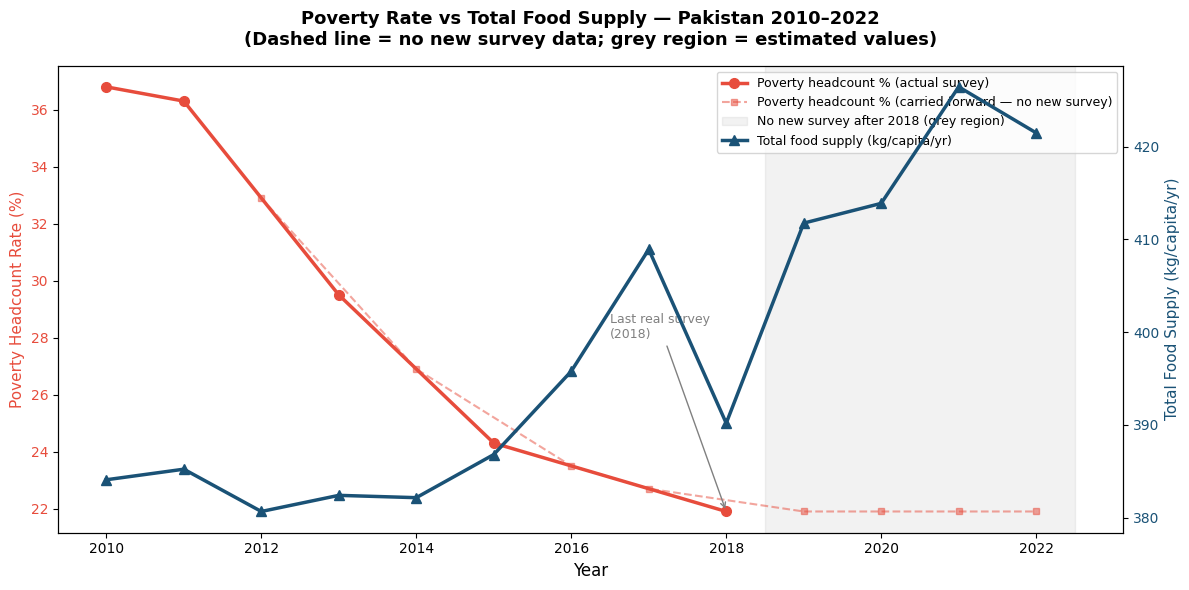

In [31]:
# ── Plot ──────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Poverty line: solid for real data, dashed for imputed
ax1.plot(real_pov['Year'], real_pov['Poverty_headcount_national_pct'],
         color='#E74C3C', linewidth=2.5, marker='o', markersize=7,
         label='Poverty headcount % (actual survey)')
if len(imputed) > 0:
    ax1.plot(imputed['Year'], imputed['Poverty_headcount_national_pct'],
             color='#E74C3C', linewidth=1.5, linestyle='--', marker='s',
             markersize=5, alpha=0.5,
             label='Poverty headcount % (carried forward — no new survey)')

# Shade the imputed region in light grey
ax1.axvspan(2018.5, 2022.5, alpha=0.10, color='grey',
            label='No new survey after 2018 (grey region)')

# Food supply line
ax2.plot(merged['Year'], merged['Total_Food_Supply_kg'],
         color='#1A5276', linewidth=2.5, marker='^', markersize=7,
         label='Total food supply (kg/capita/yr)')

# Labels
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Poverty Headcount Rate (%)', color='#E74C3C', fontsize=11)
ax2.set_ylabel('Total Food Supply (kg/capita/yr)', color='#1A5276', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#E74C3C')
ax2.tick_params(axis='y', labelcolor='#1A5276')

plt.title('Poverty Rate vs Total Food Supply — Pakistan 2010–2022\n'
          '(Dashed line = no new survey data; grey region = estimated values)',
          fontsize=13, fontweight='bold', pad=15)

# Annotation: explain the flatline
ax1.annotate('Last real survey\n(2018)', xy=(2018, 21.9),
             xytext=(2016.5, 28),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=9, color='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('eda2_poverty_vs_food_supply_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()


# EDA 4 (FIXED) — Income Inequality vs Food Supply
* Fix 1: Use only REAL survey years (2010, 2011, 2013, 2015, 2018)
* Fix 2: Use correct food supply totals from fixed FAO file
* Fix 3: Honest interpretation — do NOT over-claim from 5 data points
# ─────────────────────────────────────────────────────────────


In [32]:
# ── Real survey years only ────────────────────────────────
# wb_real was loaded at the top of the notebook
wb_eda4 = wb_real[(wb_real['Year'] >= 2010) & (wb_real['Year'] <= 2018)]

# ── Correct food supply totals ─────────────────────────────
food_rows = fao[fao['Element'] == 'Food supply quantity (kg/capita/yr)']
year_cols_fao = [str(y) for y in range(2010, 2023)]
food_totals = food_rows[year_cols_fao].sum(axis=0).reset_index()
food_totals.columns = ['Year', 'Total_Food_Supply_kg']
food_totals['Year'] = food_totals['Year'].astype(int)

# ── Merge: only keep rows where BOTH Gini and food supply exist ─
merged_eda4 = pd.merge(
    wb_eda4[['Year', 'Gini_index']].dropna(),
    food_totals, on='Year', how='inner'
)
print(f'Data points for EDA 4: {len(merged_eda4)} (only real survey years)')
print(merged_eda4.to_string())


Data points for EDA 4: 5 (only real survey years)
   Year  Gini_index  Total_Food_Supply_kg
0  2010        28.8                384.08
1  2011        29.7                385.22
2  2013        29.5                382.40
3  2015        31.3                386.80
4  2018        29.6                390.18


In [33]:
# ── Compute correlation (honest — state limitations clearly) ─
if len(merged_eda4) >= 4:
    r, p = stats.pearsonr(merged_eda4['Gini_index'],
                          merged_eda4['Total_Food_Supply_kg'])
    slope, intercept, _, _, _ = stats.linregress(
        merged_eda4['Gini_index'], merged_eda4['Total_Food_Supply_kg']
    )
    print(f'\nr = {r:.3f}, p = {p:.3f}')
    print('NOTE: With only', len(merged_eda4), 'data points,',
          'this correlation is exploratory only, not definitive.')



r = 0.314, p = 0.607
NOTE: With only 5 data points, this correlation is exploratory only, not definitive.


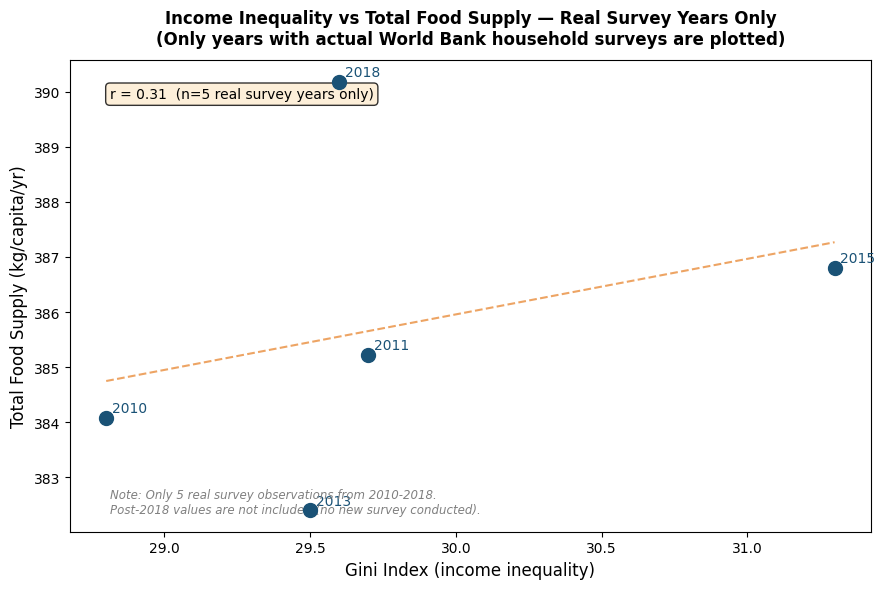

In [34]:
# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(merged_eda4['Gini_index'], merged_eda4['Total_Food_Supply_kg'],
           color='#1A5276', s=100, zorder=5)

# Label each point with its year
for _, row in merged_eda4.iterrows():
    ax.annotate(str(int(row['Year'])),
                xy=(row['Gini_index'], row['Total_Food_Supply_kg']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=10, color='#1A5276')

# Trend line (only if 4+ real points)
if len(merged_eda4) >= 4:
    x_line = np.linspace(merged_eda4['Gini_index'].min(),
                         merged_eda4['Gini_index'].max(), 50)
    ax.plot(x_line, slope * x_line + intercept,
            color='#E67E22', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(0.05, 0.92, f'r = {r:.2f}  (n={len(merged_eda4)} real survey years only)',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='#FDEBD0', alpha=0.8))

ax.set_xlabel('Gini Index (income inequality)', fontsize=12)
ax.set_ylabel('Total Food Supply (kg/capita/yr)', fontsize=12)
plt.title('Income Inequality vs Total Food Supply — Real Survey Years Only\n'
          '(Only years with actual World Bank household surveys are plotted)',
          fontsize=12, fontweight='bold', pad=12)

# Honest data limitation note directly on the chart
ax.text(0.05, 0.04,
        'Note: Only 5 real survey observations from 2010-2018.\n'
        'Post-2018 values are not included (no new survey conducted).',
        transform=ax.transAxes, fontsize=8.5, color='grey',
        style='italic')

plt.tight_layout()
plt.savefig('eda4_gini_vs_food_supply_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()



# ─────────────────────────────────────────────────────────────
# NEW EDA 8 — Wheat Dependency Trend (2010–2023)
* Dataset: fao_food_supply_clean_FIXED.csv
* Research Question: Is Pakistan's food supply dangerously concentrated on wheat, and is this dependency changing?
# ─────────────────────────────────────────────────────────────


In [35]:
# ── Filter FAO to food supply quantity only ───────────────
food_only = fao[fao['Element'] == 'Food supply quantity (kg/capita/yr)'].copy()

# ── Year columns (2010–2023) ──────────────────────────────
year_cols = [str(y) for y in range(2010, 2024)]

# ── Total food supply per year (sum across ALL items) ─────
total_by_year = food_only[year_cols].sum(axis=0)

# ── Wheat supply per year ─────────────────────────────────
wheat_row = food_only[food_only['Item'] == 'Wheat and products']
wheat_by_year = wheat_row[year_cols].iloc[0]

# ── Compute wheat as percentage of total food supply ──────
wheat_pct = (wheat_by_year / total_by_year * 100).round(2)
wheat_pct.index = wheat_pct.index.astype(int)  # convert '2010' → 2010

print('Wheat share of total food supply by year (%):')
print(wheat_pct.to_string())
print(f'\nRange: {wheat_pct.min():.1f}% to {wheat_pct.max():.1f}%')


Wheat share of total food supply by year (%):
2010    29.71
2011    25.18
2012    27.83
2013    27.54
2014    25.78
2015    25.51
2016    25.20
2017    24.88
2018    25.76
2019    25.98
2020    26.21
2021    26.02
2022    25.79
2023    25.62

Range: 24.9% to 29.7%


In [36]:
# ── Also compute top 5 food items share ───────────────────
item_means = food_only.set_index('Item')[year_cols].mean(axis=1)
total_mean = item_means.sum()
top5 = item_means.nlargest(5)
print('\nTop 5 food items (average kg/cap/yr across 2010-2023):')
for item, val in top5.items():
    print(f'  {item:<35} {val:.1f} kg  ({val/total_mean*100:.1f}%)')



Top 5 food items (average kg/cap/yr across 2010-2023):
  Milk - Excluding Butter             114.1 kg  (28.6%)
  Wheat and products                  104.7 kg  (26.2%)
  Sugar (Raw Equivalent)              23.3 kg  (5.8%)
  Rice and products                   20.7 kg  (5.2%)
  Fruits, other                       19.8 kg  (5.0%)


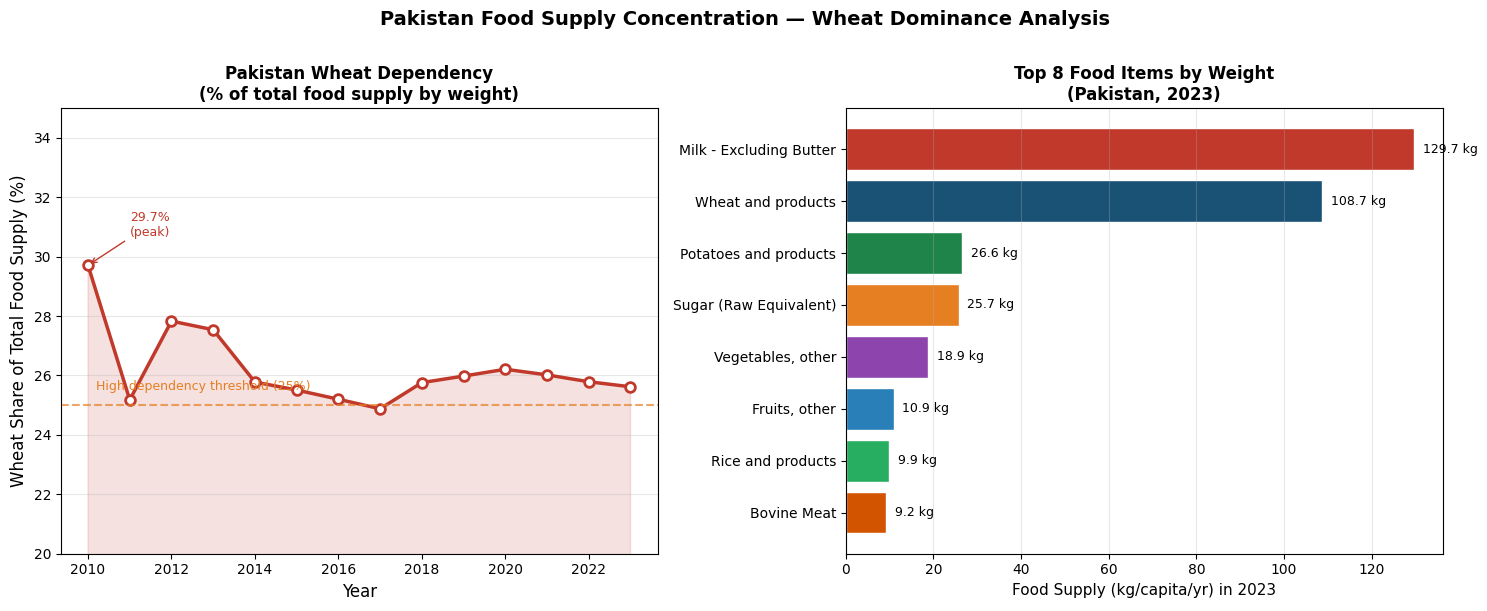

In [37]:
# ── Plot ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Wheat dependency trend
years_int = [int(y) for y in year_cols]
ax1.plot(years_int, wheat_pct.values, color='#C0392B', linewidth=2.5,
         marker='o', markersize=7, markerfacecolor='white',
         markeredgecolor='#C0392B', markeredgewidth=2)
ax1.fill_between(years_int, wheat_pct.values, alpha=0.15, color='#C0392B')

# Add danger zone shading above 25%
ax1.axhline(25, color='#E67E22', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.text(2010.2, 25.5, 'High dependency threshold (25%)',
         fontsize=9, color='#E67E22')

# Annotate peak and lowest points
peak_year = wheat_pct.idxmax()
low_year  = wheat_pct.idxmin()
ax1.annotate(f'{wheat_pct[peak_year]:.1f}%\n(peak)',
             xy=(peak_year, wheat_pct[peak_year]),
             xytext=(peak_year+1, wheat_pct[peak_year]+1),
             fontsize=9, color='#C0392B',
             arrowprops=dict(arrowstyle='->', color='#C0392B'))

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Wheat Share of Total Food Supply (%)', fontsize=12)
ax1.set_title('Pakistan Wheat Dependency\n(% of total food supply by weight)',
              fontsize=12, fontweight='bold')
ax1.set_ylim(20, 35)
ax1.grid(axis='y', alpha=0.3)

# Right: Top 5 items pie-ish bar chart for most recent year (2023)
food_2023 = food_only[year_cols[-1:]].rename(columns={year_cols[-1]: 'val'})
food_2023['Item'] = food_only['Item'].values
food_2023 = food_2023.sort_values('val', ascending=False).head(8)

colors_bar = ['#C0392B', '#1A5276', '#1E8449', '#E67E22',
              '#8E44AD', '#2980B9', '#27AE60', '#D35400']
ax2.barh(food_2023['Item'], food_2023['val'],
         color=colors_bar, edgecolor='white')

# Add value labels
for i, (item, val) in enumerate(zip(food_2023['Item'], food_2023['val'])):
    ax2.text(val + 2, i, f'{val:.1f} kg', va='center', fontsize=9)

ax2.set_xlabel('Food Supply (kg/capita/yr) in 2023', fontsize=11)
ax2.set_title('Top 8 Food Items by Weight\n(Pakistan, 2023)',
              fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Pakistan Food Supply Concentration — Wheat Dominance Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda8_wheat_dependency.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# NEW EDA 9 — Protein Adequacy vs WHO Standard (2010–2023)
* Dataset: fao_food_supply_clean_FIXED.csv
* This analysis was incorrectly skipped in Phase 2 due to a misdiagnosed data issue. The protein data is correct in the fixed FAO file. Total protein 2022 = 72.78 g/cap/day.
# ─────────────────────────────────────────────────────────────


In [38]:
# ── Filter to protein supply rows only ────────────────────
protein_rows = fao[fao['Element'] == 'Protein supply quantity (g/capita/day)'].copy()
year_cols = [str(y) for y in range(2010, 2024)]

# ── Total protein per year ────────────────────────────────
total_protein = protein_rows[year_cols].sum(axis=0)
total_protein.index = total_protein.index.astype(int)

print('Total protein by year (g/cap/day):')
print(total_protein.round(2).to_string())


Total protein by year (g/cap/day):
2010    66.87
2011    65.26
2012    65.14
2013    67.15
2014    64.96
2015    67.78
2016    66.56
2017    69.92
2018    68.80
2019    70.93
2020    72.19
2021    73.94
2022    72.78
2023    73.32


In [39]:
# ── Protein by food group (2022, top 10) ──────────────────
protein_2022 = protein_rows[['Item', '2022']].copy()
protein_2022.columns = ['Item', 'Protein_2022']
protein_2022 = protein_2022.sort_values('Protein_2022', ascending=False)
top10_protein = protein_2022.head(10)

print('\nTop 10 protein sources in 2022 (g/cap/day):')
print(top10_protein.to_string())



Top 10 protein sources in 2022 (g/cap/day):
                           Item  Protein_2022
172          Wheat and products         30.95
128     Milk - Excluding Butter         19.74
96                  Bovine Meat          4.34
151                Poultry Meat          3.67
152  Pulses, Other and products          2.11
155           Rice and products          1.95
132          Mutton & Goat Meat          1.54
112                        Eggs          1.16
150       Potatoes and products          1.08
125          Maize and products          1.00


In [45]:
# Wheat protein contribution
wheat_protein_2022 = float(
    protein_rows[protein_rows['Item'] == 'Wheat and products']['2022'].values[0]
)

total_2022 = total_protein[2022]

wheat_share = wheat_protein_2022 / total_2022 * 100

print(
    f"\nWheat protein share (2022): "
    f"{wheat_protein_2022:.2f} g out of "
    f"{total_2022:.2f} g = {wheat_share:.1f}%"
)


Wheat protein share (2022): 30.95 g out of 72.78 g = 42.5%


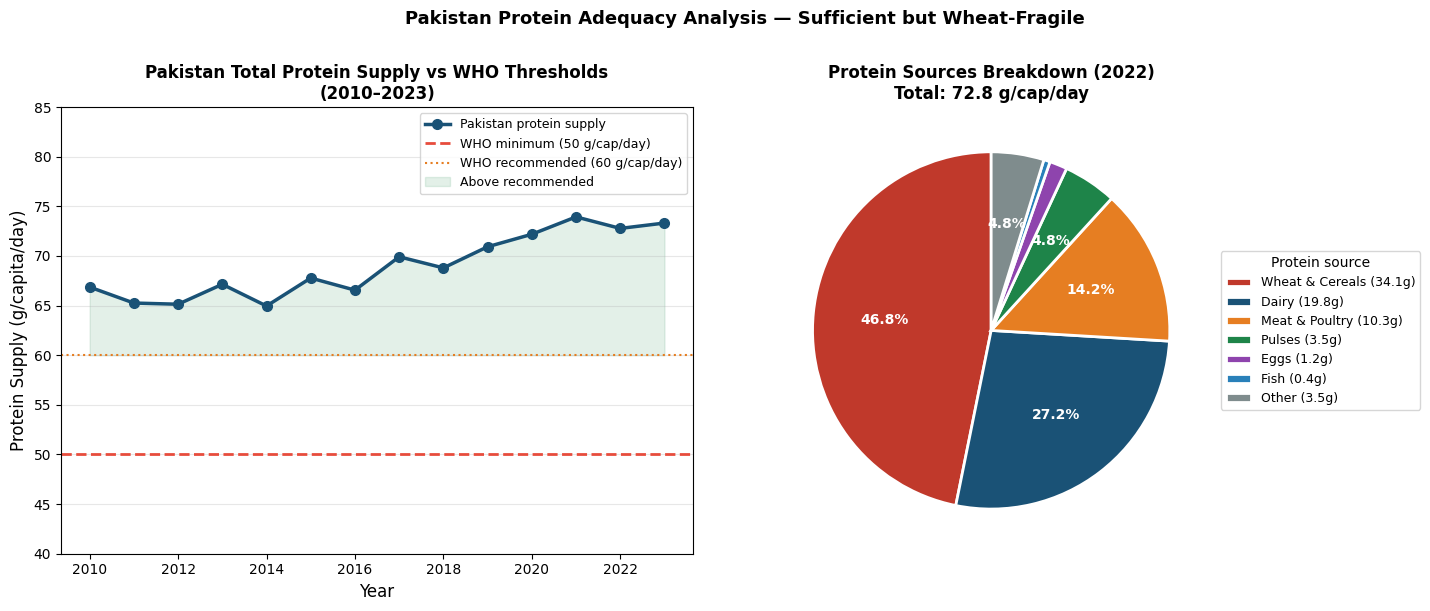

In [52]:
# ── Plot: 2 panels ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Total protein trend vs WHO thresholds
years = list(range(2010, 2024))
ax1.plot(years, total_protein.values, color='#1A5276', linewidth=2.5,
         marker='o', markersize=7, label='Pakistan protein supply')

# WHO threshold lines
ax1.axhline(50, color='#E74C3C', linewidth=2, linestyle='--',
            label='WHO minimum (50 g/cap/day)')
ax1.axhline(60, color='#E67E22', linewidth=1.5, linestyle=':',
            label='WHO recommended (60 g/cap/day)')

# Shade the 'safe zone' above 60
ax1.fill_between(years, 60, total_protein.values,
                 where=[v >= 60 for v in total_protein.values],
                 alpha=0.12, color='#1E8449', label='Above recommended')

ax1.set_ylim(40, 85)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Protein Supply (g/capita/day)', fontsize=12)
ax1.set_title('Pakistan Total Protein Supply vs WHO Thresholds\n(2010–2023)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Protein breakdown by source (2022)
# Group into major categories for clarity
categories = {
    'Wheat & Cereals': ['Wheat and products', 'Rice and products',
                         'Maize and products', 'Barley and products',
                         'Millet and products', 'Sorghum and products',
                         'Cereals, other'],
    'Dairy': ['Milk - Excluding Butter', 'Butter, Ghee', 'Cream'],
    'Meat & Poultry': ['Bovine Meat', 'Mutton & Goat Meat', 'Poultry Meat',
                        'Meat, Other', 'Offals, Edible'],
    'Pulses': ['Pulses, Other and products', 'Beans', 'Peas'],
    'Eggs': ['Eggs'],
    'Fish': ['Freshwater Fish', 'Demersal Fish', 'Pelagic Fish',
              'Marine Fish, Other'],
    'Other': []  # catch-all
}

cat_totals = {}
assigned_items = []
for cat, items in categories.items():
    if cat == 'Other':
        continue
    cat_val = protein_rows[protein_rows['Item'].isin(items)]['2022'].sum()
    cat_totals[cat] = round(cat_val, 2)
    assigned_items.extend(items)
cat_totals['Other'] = round(
    total_2022 - sum(cat_totals.values()), 2)

cats  = list(cat_totals.keys())
vals  = list(cat_totals.values())
colors_pie = ['#C0392B','#1A5276','#E67E22','#1E8449','#8E44AD','#2980B9','#7F8C8D']


wedges, texts, autotexts = ax2.pie(
    vals, labels=None, colors=colors_pie,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',  # hide label if slice < 3%
    startangle=90,
    pctdistance=0.60,   # move percentages closer to center so they fit
    wedgeprops=dict(edgecolor='white', linewidth=2))

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    # dark text on light slices, white on dark slices
    at.set_color('white')

ax2.legend(wedges, [f'{c} ({v:.1f}g)' for c,v in zip(cats,vals)],
           title='Protein source', loc='center left',
           bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax2.set_title('Protein Sources Breakdown (2022)\n'
              f'Total: {total_2022:.1f} g/cap/day',
              fontsize=12, fontweight='bold')

plt.suptitle('Pakistan Protein Adequacy Analysis — Sufficient but Wheat-Fragile',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda9_protein_adequacy.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# NEW EDA 10 — Province-Level Food Price Comparison
* Dataset: spi_prices_clean_FIXED.csv (has Province column)
* This was a gap in Phase 2 — all 7 original EDAs were city-level or national, never provincial. This addresses that gap.
# ─────────────────────────────────────────────────────────────


In [47]:
# ── Load and filter ───────────────────────────────────────
# spi_food was loaded at the top of the notebook (food items only,
# reliable rows only, Quetta wheat flour excluded)

# Define a 10-item food basket (same as EDA 3)
BASKET_ITEMS = [
    'Wheat Flour Bag',
    'Rice Irri-6/9 (Sindh/Punjab)',
    'Milk Fresh (Un-Boiled)',
    'Eggs Hen (Farm)',
    'Pulse Gram',
    'Pulse Masoor (Washed)',
    'Sugar Refined',
    'Vegetable Ghee Dalda/Habib Or Other',  # use the consolidated alias name
    'Tomatoes',
    'Onions',
]

basket_df = spi_food[spi_food['Item'].isin(BASKET_ITEMS)].copy()

print(f'Basket items found in data: {basket_df["Item"].nunique()} of {len(BASKET_ITEMS)}')
print('Items found:', sorted(basket_df['Item'].unique()))


Basket items found in data: 10 of 10
Items found: ['Eggs Hen (Farm)', 'Milk Fresh (Un-Boiled)', 'Onions', 'Pulse Gram', 'Pulse Masoor (Washed)', 'Rice Irri-6/9 (Sindh/Punjab)', 'Sugar Refined', 'Tomatoes', 'Vegetable Ghee Dalda/Habib Or Other', 'Wheat Flour Bag']


In [48]:
# ── Province-level average basket cost ────────────────────
# Step 1: average price per item per province
prov_item_avg = basket_df.groupby(['Province', 'Item'])['Avg_Price'].mean()

# Step 2: sum all basket items per province
basket_by_province = prov_item_avg.groupby('Province').sum().reset_index()
basket_by_province.columns = ['Province', 'Basket_Cost_PKR']
basket_by_province = basket_by_province.sort_values('Basket_Cost_PKR',
                                                      ascending=False)
print('\nAverage basket cost by province:')
print(basket_by_province.to_string())



Average basket cost by province:
      Province  Basket_Cost_PKR
1          ICT      4981.082762
4        Sindh      4728.971833
3       Punjab      4706.078140
2          KPK      3830.246500
0  Balochistan      1483.651143


In [49]:
# ── Add provincial wages ──────────────────────────────────
prov_wages = {
    'ICT'         : 53000,
    'Punjab'      : 43000,
    'Sindh'       : 47000,
    'KPK'         : 32000,
    'Balochistan' : 28000,
}
basket_by_province['Avg_Monthly_Wage_PKR'] = basket_by_province['Province'].map(prov_wages)
basket_by_province['Affordability_Pct'] = (
    basket_by_province['Basket_Cost_PKR'] /
    basket_by_province['Avg_Monthly_Wage_PKR'] * 100
).round(1)

print('\nProvince-level affordability:')
print(basket_by_province.to_string())



Province-level affordability:
      Province  Basket_Cost_PKR  Avg_Monthly_Wage_PKR  Affordability_Pct
1          ICT      4981.082762                 53000                9.4
4        Sindh      4728.971833                 47000               10.1
3       Punjab      4706.078140                 43000               10.9
2          KPK      3830.246500                 32000               12.0
0  Balochistan      1483.651143                 28000                5.3


In [50]:
# ── Province-level price inflation (Aug 2023 vs latest) ───
basket_df_sorted = basket_df.sort_values('Date')
first_prices = basket_df_sorted.groupby(['Province', 'Item'])['Avg_Price'].first()
last_prices  = basket_df_sorted.groupby(['Province', 'Item'])['Avg_Price'].last()
prov_inflation = ((last_prices - first_prices) / first_prices * 100).groupby('Province').mean()
prov_inflation = prov_inflation.reset_index()
prov_inflation.columns = ['Province', 'Avg_Inflation_Pct']

print('\nAverage food price inflation by province:')
print(prov_inflation.to_string())



Average food price inflation by province:
      Province  Avg_Inflation_Pct
0  Balochistan           2.231712
1          ICT           1.640993
2          KPK          37.603046
3       Punjab          22.316975
4        Sindh           2.383338


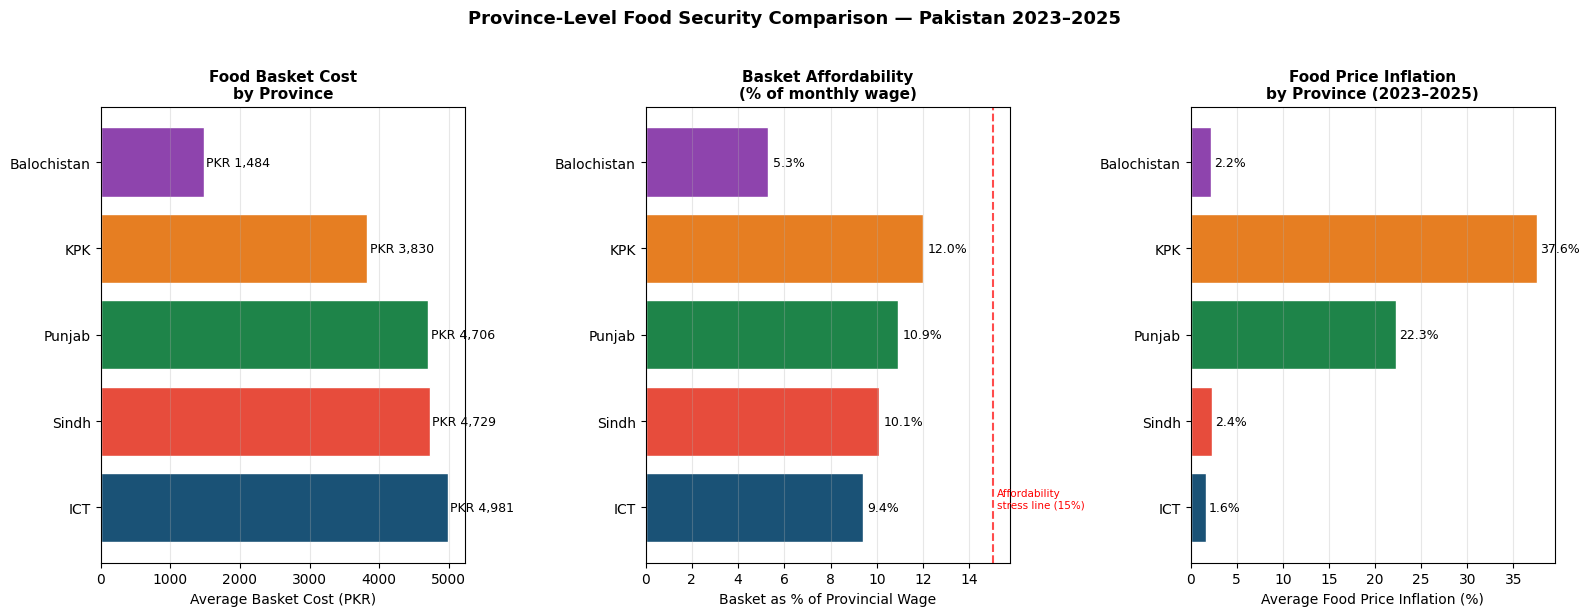

In [51]:
# ── Plot: 3-panel province comparison ─────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

colors_prov = {'ICT': '#1A5276', 'Punjab': '#1E8449',
               'Sindh': '#E74C3C', 'KPK': '#E67E22', 'Balochistan': '#8E44AD'}

# Panel 1: Basket cost
provs  = basket_by_province['Province']
costs  = basket_by_province['Basket_Cost_PKR']
bar_colors1 = [colors_prov.get(p, '#5D6D7E') for p in provs]
bars1 = ax1.barh(provs, costs, color=bar_colors1, edgecolor='white')
for bar, val in zip(bars1, costs):
    ax1.text(val + 30, bar.get_y() + bar.get_height()/2,
             f'PKR {val:,.0f}', va='center', fontsize=9)
ax1.set_xlabel('Average Basket Cost (PKR)', fontsize=10)
ax1.set_title('Food Basket Cost\nby Province', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Panel 2: Affordability (% of wage)
provs2 = basket_by_province['Province']
afford = basket_by_province['Affordability_Pct']
bar_colors2 = [colors_prov.get(p, '#5D6D7E') for p in provs2]
bars2 = ax2.barh(provs2, afford, color=bar_colors2, edgecolor='white')
for bar, val in zip(bars2, afford):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
ax2.axvline(15, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.text(15.2, 0, 'Affordability\nstress line (15%)', fontsize=7.5, color='red')
ax2.set_xlabel('Basket as % of Provincial Wage', fontsize=10)
ax2.set_title('Basket Affordability\n(% of monthly wage)', fontsize=11,
              fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Panel 3: Inflation by province
merged_inf = pd.merge(basket_by_province[['Province']], prov_inflation, on='Province')
bar_colors3 = [colors_prov.get(p, '#5D6D7E') for p in merged_inf['Province']]
bars3 = ax3.barh(merged_inf['Province'], merged_inf['Avg_Inflation_Pct'],
                  color=bar_colors3, edgecolor='white')
for bar, val in zip(bars3, merged_inf['Avg_Inflation_Pct']):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
ax3.set_xlabel('Average Food Price Inflation (%)', fontsize=10)
ax3.set_title('Food Price Inflation\nby Province (2023–2025)', fontsize=11,
              fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Province-Level Food Security Comparison — Pakistan 2023–2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda10_province_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
